In [2]:
import pandas as pd


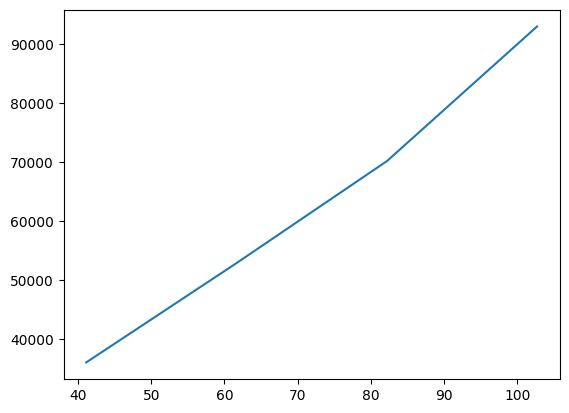

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#ff kijken hoe zon grafiek er uit zou zien
#array voor spanning en grondtoon (boventonen), bij spanningsverandering, oefenmetingen, met oog afgelezenv
T= np.array([102.7,82.2,61.6,41.1])
f_1= np.array([305.0,265.0,230.0,190.0])
f_2= []
f_3= []


plt.figure()
plt.plot(T,f_1**2)
plt.show()

mu = 0.003220 ± 0.000085 kg/m
a = 774.90 ± 24.36


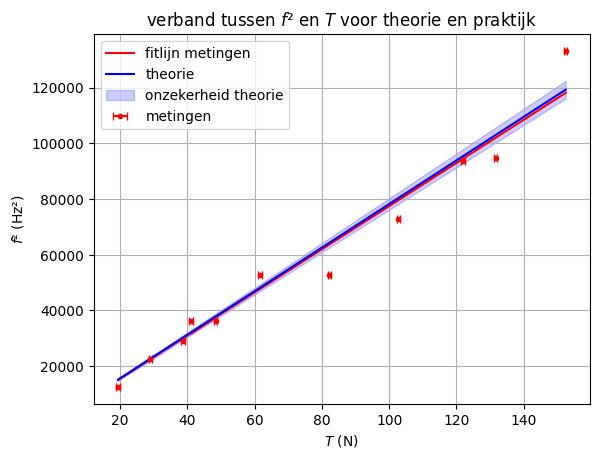

Gemiddelde residu: -550.65
Standaarddeviatie residuen: 7007.91


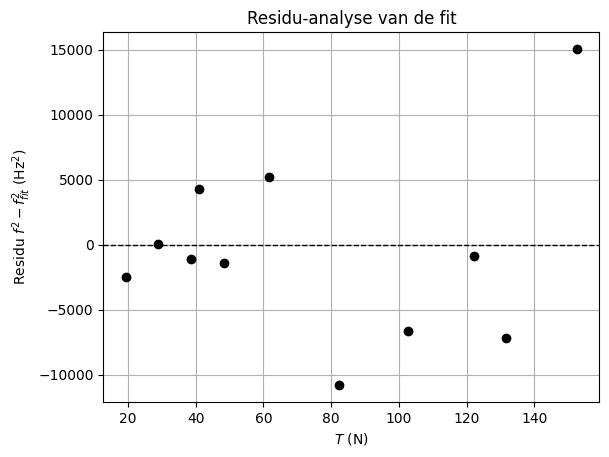

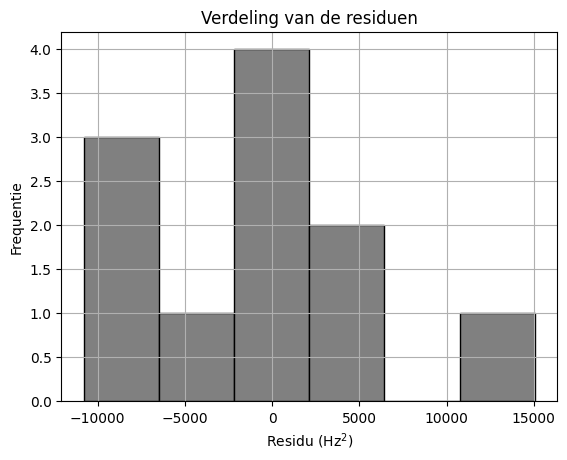

R² = 0.9639
a_theorie = 782.38 ± 20.75
a_fit     = 774.90 ± 24.36
Verschil tussen a_fit en a_theorie: 7.48
Gecombineerde onzekerheid: 32.00
De twee waarden komen overeen binnen de meetonzekerheid.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- gegeven waarden en fouten ---
L = 0.315          # m
sigma_L = 0.0005   # m  (0.05 cm)

m_snaar = 0.0019        # kg  (1.9 g)
sigma_m_snaar = 0.00005 # kg  (0.05 g)
L_snaar = 0.59          # m
sigma_L_snaar = 0.0005  # m  (0.05 cm)

mu = m_snaar / L_snaar
sigma_mu = mu * np.sqrt((sigma_m_snaar/m_snaar)**2 + (sigma_L_snaar/L_snaar)**2)
print(f"mu = {mu:.6f} ± {sigma_mu:.6f} kg/m")

g = 9.81
sigma_m = 0.05      # kg, meetfout op de massa waarmee T bepaald is
constante = 1       # <-- pas aan als jullie een andere factor gebruikten

# fout op T: T = m*g*constante  ->  sigma_T = g*constante*sigma_m
sigma_T = g * constante * sigma_m   # zelfde absolute fout voor elk punt

T_m = np.array([152.5,131.7,122.0,102.7,82.2,61.6,41.1,48.4,38.7,29.0,19.4])
f_g = np.array([365.0,308.0,306.0,270.0,230.0,230.0,190.0,190.0,170.0,150.0,112.0])

def lineair(x, a):      # let op: x moet eerst, anders klopt curve_fit niet
    return a * x

x = T_m
y = f_g**2

popt, pcov = curve_fit(lineair, x, y)
a = popt[0]
a_err = np.sqrt(pcov[0,0])
print(f"a = {a:.2f} ± {a_err:.2f}")

T_theorie = np.linspace(min(T_m), max(T_m), 200)

def i_snaartheorie(T):
    return 1/(4*L**2) * T/mu

y_theorie = i_snaartheorie(T_theorie)

# onzekerheidsband op de theoretische lijn via foutvoortplanting
rel_fout = np.sqrt((2*sigma_L/L)**2 + (sigma_mu/mu)**2)
y_theorie_fout = y_theorie * rel_fout

plt.figure()
plt.errorbar(T_m, f_g**2, xerr=sigma_T, fmt='r.', capsize=3, label='metingen')
plt.plot(T_m, lineair(T_m, a), 'r-', label='fitlijn metingen')
plt.plot(T_theorie, y_theorie, 'b-', label='theorie')
plt.fill_between(T_theorie, y_theorie - y_theorie_fout, y_theorie + y_theorie_fout,
                  color='blue', alpha=0.2, label='onzekerheid theorie')
plt.xlabel("$T$ (N)")
plt.ylabel('$f²$ (Hz²)')
plt.legend()
plt.grid()
plt.title("verband tussen $f²$ en $T$ voor theorie en praktijk")
plt.savefig("verbandTenf.png")
plt.show()

# --- Residu-analyse ---
residuen = f_g**2 - y_pred   # verschil tussen meting en fit

# Basisstatistieken van de residuen
print(f"Gemiddelde residu: {np.mean(residuen):.2f}")
print(f"Standaarddeviatie residuen: {np.std(residuen, ddof=1):.2f}")

# Residuen tegen T (checken op patronen)
plt.figure()
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.plot(T_m, residuen, 'ko', markersize=6)
plt.xlabel("$T$ (N)")
plt.ylabel("Residu $f^2 - f^2_{fit}$ (Hz$^2$)")
plt.title("Residu-analyse van de fit")
plt.grid()
plt.savefig('residugrafiekfenT.png')
plt.show()

# Histogram van de residuen (check op normale verdeling)
plt.figure()
plt.hist(residuen, bins=6, color='gray', edgecolor='black')
plt.xlabel("Residu (Hz$^2$)")
plt.ylabel("Frequentie")
plt.title("Verdeling van de residuen")
plt.grid()
plt.show()

y_pred = a * T_m
y_gemiddeld = np.mean(f_g**2)
SS_res = np.sum((f_g**2 - y_pred)**2)
SS_tot = np.sum((f_g**2 - y_gemiddeld)**2)
R2 = 1 - SS_res/SS_tot
print(f"R² = {R2:.4f}")

# --- Meetfout op de theoretische coëfficiënt a_theorie = 1/(4*L^2*mu) ---

a_theorie = 1 / (4 * L**2 * mu)

# relatieve fout via foutenvoortplanting (L^2 geeft factor 2, mu^1 geeft factor 1)
rel_fout_a_theorie = np.sqrt((2 * sigma_L / L)**2 + (sigma_mu / mu)**2)
sigma_a_theorie = a_theorie * rel_fout_a_theorie

print(f"a_theorie = {a_theorie:.2f} ± {sigma_a_theorie:.2f}")

# --- Vergelijking met de gefitte waarde ---
print(f"a_fit     = {a:.2f} ± {a_err:.2f}")

verschil = abs(a - a_theorie)
gecombineerde_fout = np.sqrt(a_err**2 + sigma_a_theorie**2)
print(f"Verschil tussen a_fit en a_theorie: {verschil:.2f}")
print(f"Gecombineerde onzekerheid: {gecombineerde_fout:.2f}")

if verschil < gecombineerde_fout:
    print("De twee waarden komen overeen binnen de meetonzekerheid.")
else:
    print(f"De twee waarden verschillen met {verschil/gecombineerde_fout:.1f} keer de gecombineerde onzekerheid — mogelijk systematische afwijking.")

566.9227346522165 Hz
Vpp, gemiddelde f, fout:
  1  488.0 ± 0.0 Hz
  3  488.7 ± 0.7 Hz
  5  564.7 ± 20.3 Hz
  7  577.7 ± 2.4 Hz
  9  571.7 ± 5.8 Hz
 10  565.0 ± 4.0 Hz


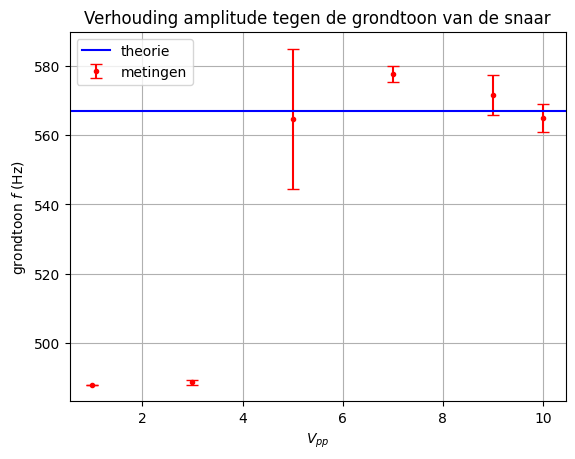

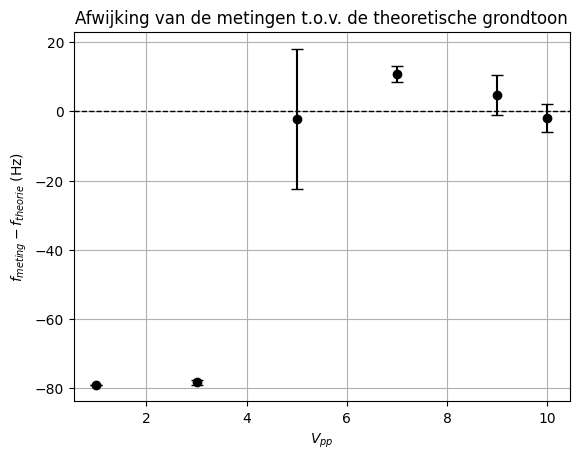

Gemiddelde afwijking: -24.311623541105394
Standaarddeviatie afwijking: 42.315963190511674


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- theorie ---
T_a = 102.7  # N
f_g1 = 1/L * np.sqrt(T_a/mu)
print(f_g1, 'Hz')

# --- metingen ---
fres_1  = np.array([488,488,488])
fres_3  = np.array([488,488,490])
fres_5  = np.array([585,585,524])
fres_7  = np.array([573,579,581])
fres_9  = np.array([581,561,573])
fres_10 = np.array([573,561,561])

alle_metingen = [fres_1, fres_3, fres_5, fres_7, fres_9, fres_10]
Vpp = np.array([1,3,5,7,9,10])

fres = np.array([np.mean(m) for m in alle_metingen])

# meetfout: standaardfout van het gemiddelde (std / sqrt(n))
sigma_fres = np.array([np.std(m, ddof=1)/np.sqrt(len(m)) for m in alle_metingen])

print("Vpp, gemiddelde f, fout:")
for v, f, s in zip(Vpp, fres, sigma_fres):
    print(f"{v:3d}  {f:.1f} ± {s:.1f} Hz")

# --- grafiek met errorbalken ---
plt.figure()
plt.errorbar(Vpp, fres, yerr=sigma_fres, fmt='r.', capsize=4, label='metingen')
plt.axhline(y=f_g1, color='b', label='theorie')
plt.xlabel('$V_{pp}$')
plt.ylabel('grondtoon $f$ (Hz)')
plt.title('Verhouding amplitude tegen de grondtoon van de snaar')
plt.legend()
plt.grid()
plt.savefig("fig_amplitude_vs_f.png", dpi=300, bbox_inches='tight')
plt.show()

# --- afwijking t.o.v. theorie (geen echte "residu-analyse" zoals bij een fit, maar wel nuttig) ---
afwijking = fres - f_g1

plt.figure()
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.errorbar(Vpp, afwijking, yerr=sigma_fres, fmt='ko', capsize=4)
plt.xlabel('$V_{pp}$')
plt.ylabel('$f_{meting} - f_{theorie}$ (Hz)')
plt.title('Afwijking van de metingen t.o.v. de theoretische grondtoon')
plt.grid()
plt.savefig("fig_afwijking_amplitude.png", dpi=300, bbox_inches='tight')
plt.show()

print("Gemiddelde afwijking:", np.mean(afwijking))
print("Standaarddeviatie afwijking:", np.std(afwijking, ddof=1))